# Human Development Index (HDI) Predictor
## A Comprehensive Measure of Well-Being
**Team:** ML-0027 | **Model:** Linear Regression | **Date:** 26 June 2026

✅ STEP 1: Dataset loaded!
Shape: (191, 6)
                Country    HDI  Life expectancy  Expected years of schooling  \
0           Afghanistan  0.478          61.9824                    10.263844   
1                Angola  0.586          61.6434                    12.172100   
2               Albania  0.796          76.4626                    14.448000   
3               Andorra  0.858          80.3684                    13.300239   
4  United Arab Emirates  0.911          78.7104                    15.717690   

   Mean years of schooling  Gross national income (GNI) per capita  
0                 2.985070                             1824.190915  
1                 5.417391                             5465.617791  
2                11.286455                            14131.110390  
3                10.555120                            51166.626610  
4                12.694030                            62573.591810  


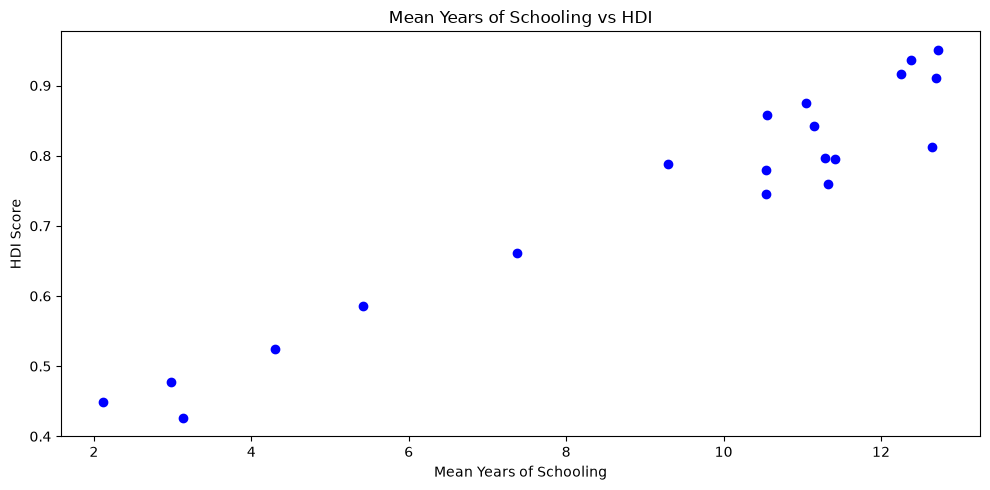

✅ Plot 1 done!


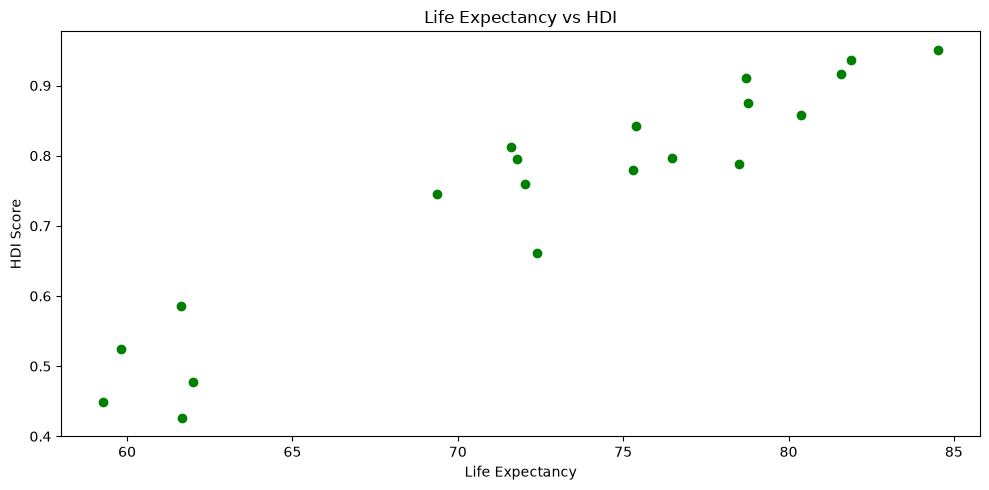

✅ Plot 2 done!


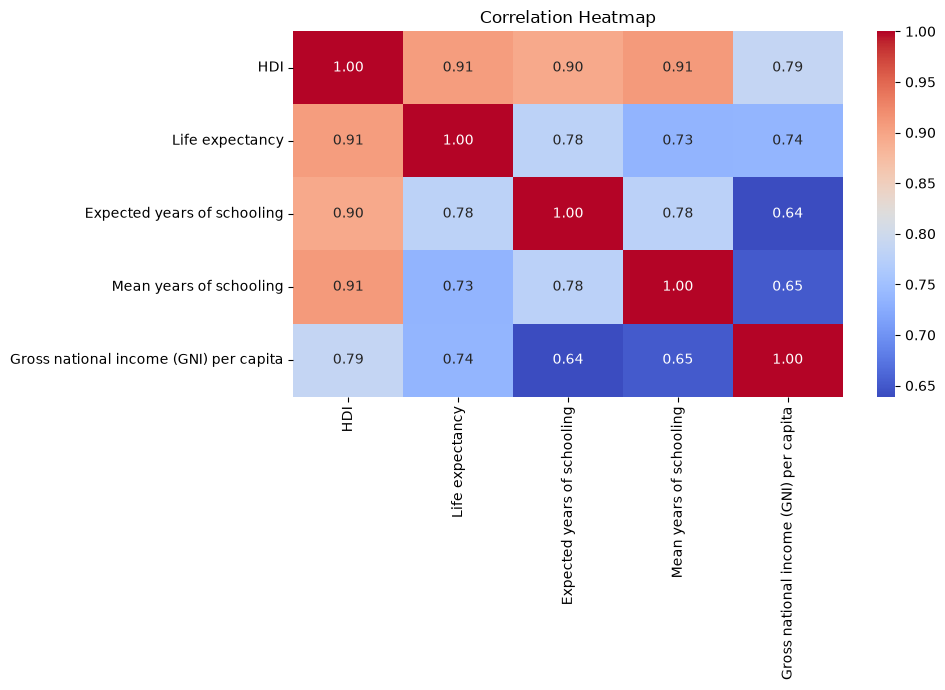

✅ Plot 3 done!

✅ STEP 3: Features selected!
X shape: (191, 4)
✅ STEP 4: Null values handled!
Life expectancy                           0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64

✅ STEP 5: Data split!
Train: (171, 4)
Test : (20, 4)

✅ STEP 6: Model trained!
✅ STEP 7: Predictions done!
Predicted: [0.50136591 0.54158702 0.71497329 0.49468136 0.68055356 0.67060195
 0.90943836 0.77527615 0.95298165 0.43260677 0.8734826  0.43679881
 0.79036892 0.96963139 0.65909996 0.74487286 0.79232624 0.51380867
 0.39752146 0.89067412]

===== Model Performance =====
R² Score : 0.9887
MAE      : 0.0166
MSE      : 0.0004
RMSE     : 0.0201
Accuracy : 98.87%


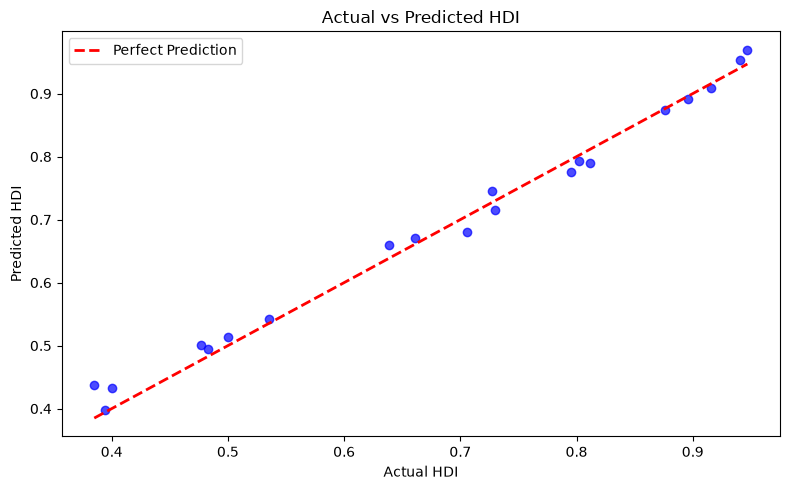

✅ Plot 4 done!

✅ STEP 10: Model saved as HDI.pkl!
✅ Verified! Test prediction: 0.6019

🎉 ALL DONE! PROJECT COMPLETE!


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:

# HDI PROJECT CODE 
 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle

# STEP 1: LOAD DATASET 
Development_raw = pd.read_csv('../Dataset/HDI.csv')

Development = pd.DataFrame()
Development['Country'] = Development_raw['Country']
Development['HDI'] = Development_raw['Human Development Index (2021)']
Development['Life expectancy'] = Development_raw['Life Expectancy at Birth (2021)']
Development['Expected years of schooling'] = Development_raw['Expected Years of Schooling (2021)']
Development['Mean years of schooling'] = Development_raw['Mean Years of Schooling (2021)']
Development['Gross national income (GNI) per capita'] = Development_raw['Gross National Income Per Capita (2021)']
Development = Development.dropna(subset=['HDI'])

print('✅ STEP 1: Dataset loaded!')
print('Shape:', Development.shape)
print(Development.head())

#  STEP 2: VISUALIZATIONS
data1 = Development.head(20).copy()

# Plot 1 - Mean Years of Schooling vs HDI
plt.figure(figsize=(10,5))
plt.scatter(data1['Mean years of schooling'], data1['HDI'], color='blue')
plt.title('Mean Years of Schooling vs HDI')
plt.xlabel('Mean Years of Schooling')
plt.ylabel('HDI Score')
plt.tight_layout()
plt.show()
print('✅ Plot 1 done!')

# Plot 2 - Life Expectancy vs HDI
plt.figure(figsize=(10,5))
plt.scatter(data1['Life expectancy'], data1['HDI'], color='green')
plt.title('Life Expectancy vs HDI')
plt.xlabel('Life Expectancy')
plt.ylabel('HDI Score')
plt.tight_layout()
plt.show()
print('✅ Plot 2 done!')

# Plot 3 - Correlation Heatmap
plt.figure(figsize=(10,7))
heat = Development[['HDI','Life expectancy',
                     'Expected years of schooling',
                     'Mean years of schooling',
                     'Gross national income (GNI) per capita']]
sns.heatmap(heat.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print('✅ Plot 3 done!')

# ── STEP 3: SELECT FEATURES ───────────────
X = Development[['Life expectancy',
                  'Expected years of schooling',
                  'Mean years of schooling',
                  'Gross national income (GNI) per capita']]
y = Development['HDI']
print('\n✅ STEP 3: Features selected!')
print('X shape:', X.shape)

# ── STEP 4: HANDLE NULLS ──────────────────
X = X.copy()
X.fillna(X.mean(), inplace=True)
print('✅ STEP 4: Null values handled!')
print(X.isnull().sum())

# ── STEP 5: TRAIN TEST SPLIT ──────────────
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42)
print('\n✅ STEP 5: Data split!')
print('Train:', x_train.shape)
print('Test :', x_test.shape)

# ── STEP 6: TRAIN MODEL ───────────────────
reg = LinearRegression()
reg.fit(x_train, y_train)
print('\n✅ STEP 6: Model trained!')

# ── STEP 7: PREDICT ───────────────────────
y_pred = reg.predict(x_test)
print('✅ STEP 7: Predictions done!')
print('Predicted:', y_pred)

# ── STEP 8: EVALUATE ──────────────────────
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('\n===== Model Performance =====')
print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.4f}')
print(f'MSE      : {mse:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'Accuracy : {r2*100:.2f}%')

# ── STEP 9: ACTUAL VS PREDICTED PLOT ──────
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual HDI')
plt.ylabel('Predicted HDI')
plt.title('Actual vs Predicted HDI')
plt.legend()
plt.tight_layout()
plt.show()
print('✅ Plot 4 done!')

# ── STEP 10: SAVE MODEL ───────────────────
pickle.dump(reg, open('../Flask/HDI.pkl', 'wb'))
print('\n✅ STEP 10: Model saved as HDI.pkl!')

# Verify
loaded = pickle.load(open('../Flask/HDI.pkl', 'rb'))
test   = loaded.predict([[72.0, 10.5, 5.2, 3341.0]])
print('✅ Verified! Test prediction:', round(test[0], 4))
print('\n🎉 ALL DONE! PROJECT COMPLETE!')